# Time Series Modelling Case Study
**Name:** Bhavin Thakur  
**Student ID:** 23079699

## 0. Imports

In [1]:
import os
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy import stats
from itertools import product
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

for name in ["tensorflow", "matplotlib", "statsmodels", "sklearn", "pandas"]:
    logging.getLogger(name).setLevel(logging.ERROR)

for module in ["statsmodels", "sklearn", "pandas"]:
    warnings.filterwarnings("ignore", module=module)

for category in [UserWarning, FutureWarning, RuntimeWarning]:
    warnings.filterwarnings("ignore", category=category)


## 1. Load and Explore Data

In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath, encoding='utf-8-sig')
    df.columns = ['date', 'price']
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df = df.sort_values('date').set_index('date')
    df = df.dropna()
    return df

df = load_data('data/oil_prices_2426.csv')
print("Shape:", df.shape)
print(df.describe().round(2))

Shape: (500, 1)
        price
count  500.00
mean    75.87
std     42.91
min     16.48
25%     35.37
50%     64.29
75%    111.57
max    158.78


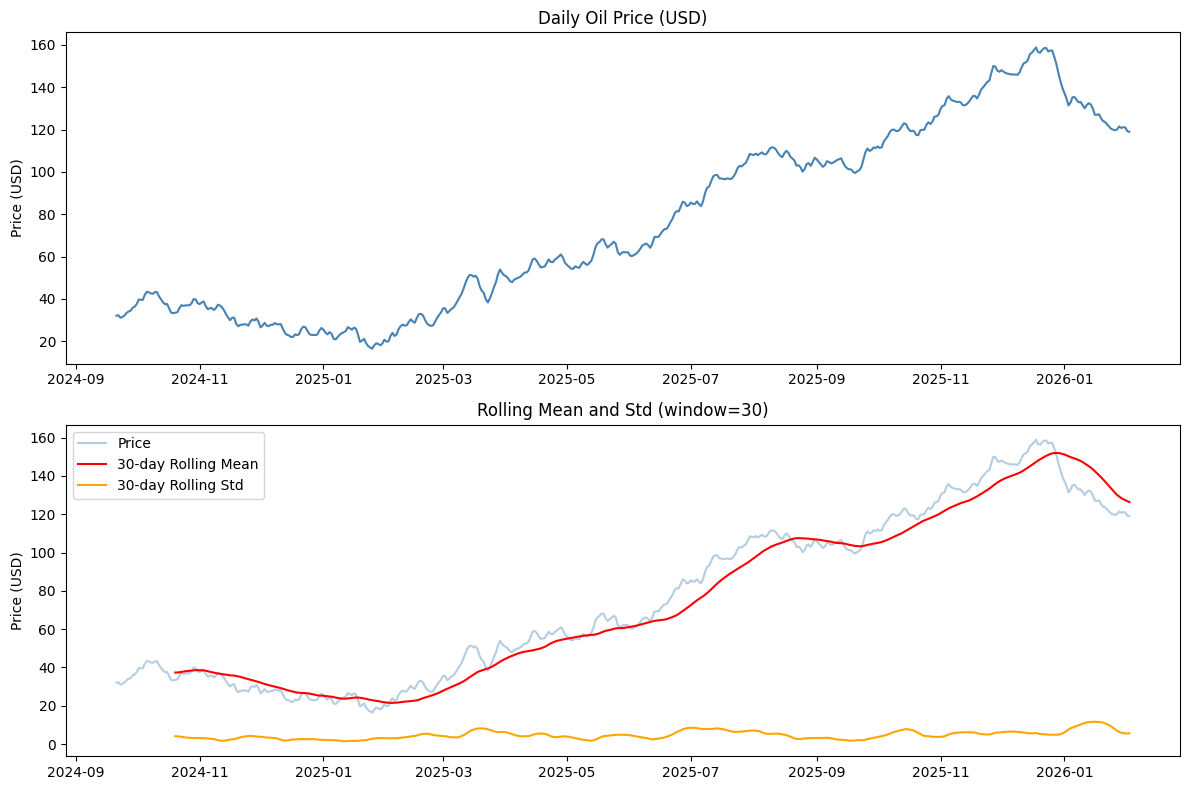

In [3]:
# Plot raw series with rolling mean and standard deviation
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df['price'], color='steelblue')
axes[0].set_title('Daily Oil Price (USD)')
axes[0].set_ylabel('Price (USD)')

roll_mean = df['price'].rolling(30).mean()
roll_std = df['price'].rolling(30).std()
axes[1].plot(df['price'], alpha=0.4, color='steelblue', label='Price')
axes[1].plot(roll_mean, color='red', label='30-day Rolling Mean')
axes[1].plot(roll_std, color='orange', label='30-day Rolling Std')
axes[1].set_title('Rolling Mean and Std (window=30)')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Stationarity Tests

Run ADF and KPSS stationarity tests

In [4]:
def adf_test(series, label=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test - {label}')
    print(f'  Statistic: {result[0]:.4f},  p-value: {result[1]:.4f}')
    print(f'  Result: {"Stationary" if result[1] < 0.05 else "Non-Stationary"}\n')
    return result[1]

def kpss_test(series, label=''):
    stat, p, _, crits = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Test - {label}')
    print(f'  Statistic: {stat:.4f},  p-value: {p:.4f}')
    print(f'  Result: {"Non-Stationary" if p < 0.05 else "Stationary"}\n')
    return p

In [5]:
def plot_acf_pacf(series, label='', save_fig=False):
    fig, ax = plt.subplots(1, 2, figsize=(14,5))

    plot_acf(series.dropna(), lags=50, ax=ax[0])
    ax[0].set_title(f'ACF - {label}')
    ax[0].set_xlabel('Lag')
    ax[0].set_ylabel('Correlation')

    plot_pacf(series.dropna(), lags=50, ax=ax[1], method='ywm')
    ax[1].set_title(f'PACF - {label}')
    ax[1].set_xlabel('Lag')
    ax[1].set_ylabel('Correlation')

    plt.tight_layout()

    if save_fig:
        filename = f"fig_acf_pacf_{label.lower().replace(' ', '_')}.png"
        plt.savefig(filename, dpi=150, bbox_inches="tight")

    plt.show()

ADF Test - Raw Price
  Statistic: -0.5462,  p-value: 0.8827
  Result: Non-Stationary

KPSS Test - Raw Price
  Statistic: 3.7056,  p-value: 0.0100
  Result: Non-Stationary



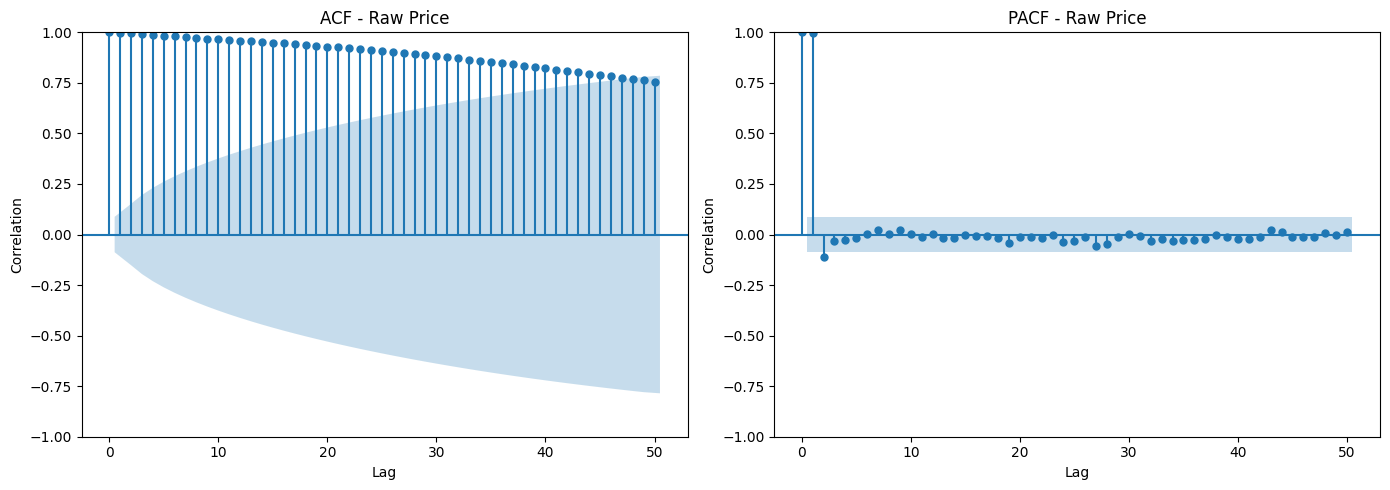

In [6]:
# Stationarity Tests
adf_test(df['price'], 'Raw Price')
kpss_test(df['price'], 'Raw Price')

# ACF/PACF Analysis
plot_acf_pacf(df['price'], 'Raw Price', save_fig=True)

## 3. Differencing

In [7]:
def difference(series, order=1):
    out = series.copy()
    for _ in range(order):
        out = out.diff().dropna()
    return out

diff1 = difference(df['price'], 1)

adf_test(diff1, '1st Order Differenced')
kpss_test(diff1, '1st Order Differenced')

ADF Test - 1st Order Differenced
  Statistic: -4.5415,  p-value: 0.0002
  Result: Stationary

KPSS Test - 1st Order Differenced
  Statistic: 0.1903,  p-value: 0.1000
  Result: Stationary



np.float64(0.1)

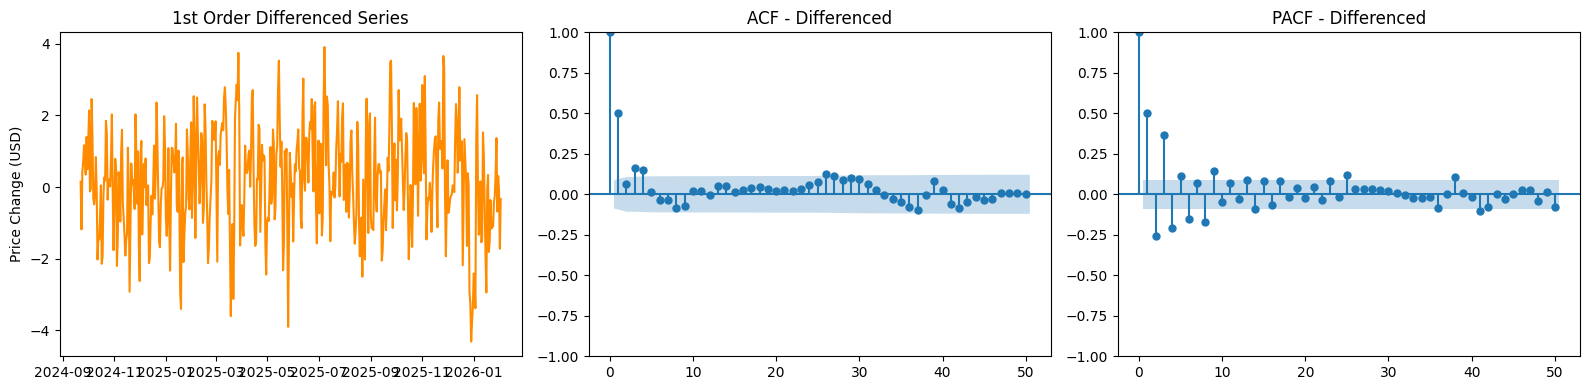

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(diff1, color='darkorange')
axes[0].set_title('1st Order Differenced Series')
axes[0].set_ylabel('Price Change (USD)')

plot_acf(diff1, lags=50, ax=axes[1], title='ACF - Differenced')
plot_pacf(diff1, lags=50, ax=axes[2], title='PACF - Differenced', method='ywm')

plt.tight_layout()
plt.savefig('fig3_differenced.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ARIMA - Grid Search for Best Parameters (AIC)

In [9]:
def arima_grid_search(series, p_vals, d_vals, q_vals):
    best_aic = np.inf
    best_order = None
    results = []
    total = len(p_vals) * len(d_vals) * len(q_vals)
    count = 0

    for p, d, q in product(p_vals, d_vals, q_vals):
        count += 1
        if count % 50 == 0:
            print(f'  {count}/{total} done...')
        try:
            model = ARIMA(series, order=(p, d, q)).fit()
            results.append({'p': p, 'd': d, 'q': q, 'AIC': round(model.aic, 2)})
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, d, q)
        except Exception:
            continue

    results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    print(f'\nBest order: ARIMA{best_order}  AIC={best_aic:.2f}')
    return best_order, results_df

print('Running grid search...')
best_order, aic_df = arima_grid_search(df['price'], range(0,9), range(0,3), range(0,9))
print('\nTop 10 by AIC:')
print(aic_df.head(10).to_string(index=False))

Running grid search...
  50/243 done...
  100/243 done...
  150/243 done...
  200/243 done...

Best order: ARIMA(2, 2, 7)  AIC=1429.22

Top 10 by AIC:
 p  d  q     AIC
 2  2  7 1429.22
 4  1  5 1429.77
 0  1  5 1429.90
 1  1  4 1430.46
 4  1  8 1430.84
 2  1  4 1430.85
 5  1  5 1430.95
 4  1  1 1431.11
 0  1  6 1431.36
 3  1  3 1431.69


## 5. Fit Best ARIMA and Check Residuals

In [10]:
arima_fit = ARIMA(df['price'], order=best_order).fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.608
Date:                Tue, 10 Mar 2026   AIC                           1429.217
Time:                        13:19:35   BIC                           1471.323
Sample:                    09-21-2024   HQIC                          1445.742
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1810      0.030    -39.396      0.000      -1.240      -1.122
ar.L2         -0.9145      0.030    -30.356      0.000      -0.974      -0.855
ma.L1          1.1487      0.451      2.547      0.0

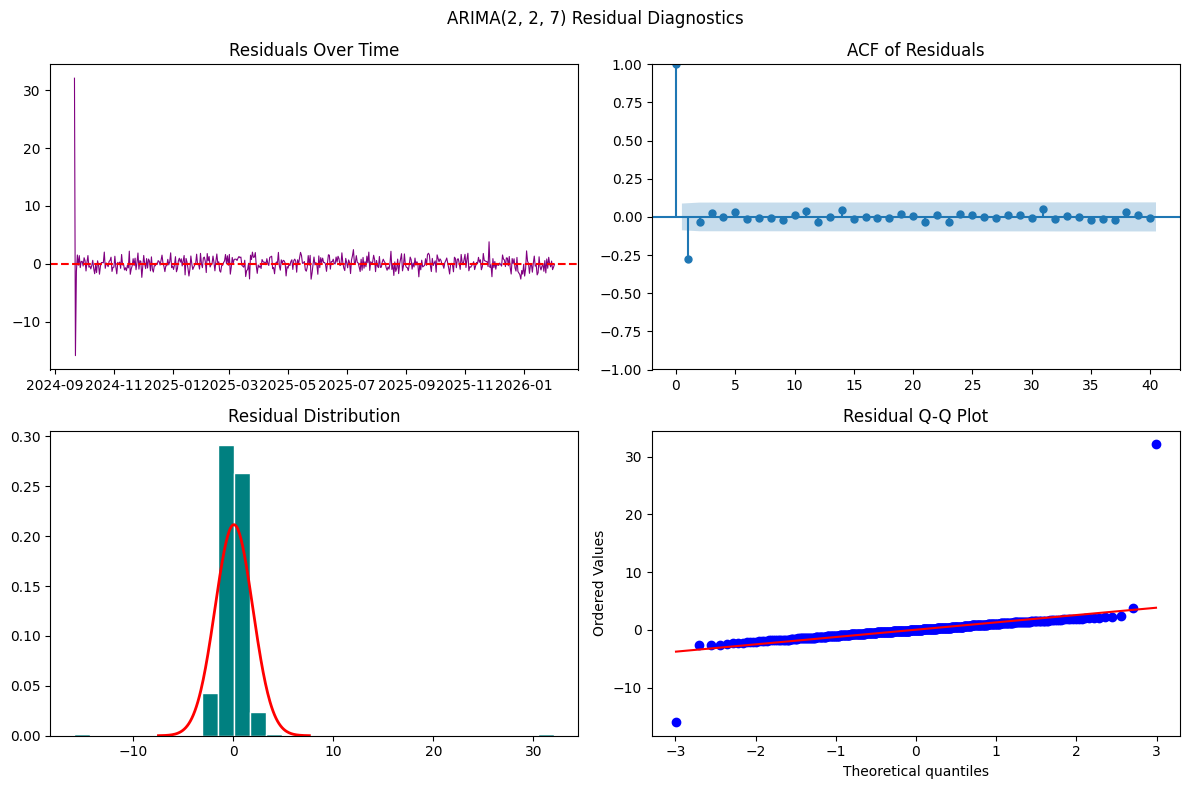

Ljung-Box Test:
      lb_stat  lb_pvalue
10  39.801004   0.000018
20  42.261593   0.002556
30  44.045466   0.047242


In [11]:
residuals = arima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals over time
axes[0, 0].plot(residuals, color='purple', lw=0.8)
axes[0, 0].axhline(0, color='red', ls='--')
axes[0, 0].set_title("Residuals Over Time")

# ACF of residuals
plot_acf(residuals.dropna(), lags=40, ax=axes[0, 1])
axes[0, 1].set_title("ACF of Residuals")

# Histogram + normal curve
clean_res = residuals.dropna()
axes[1, 0].hist(clean_res, bins=30, color='teal', edgecolor='white', density=True)

m, s = clean_res.mean(), clean_res.std()
x_vals = np.linspace(m - 4*s, m + 4*s, 200)
axes[1, 0].plot(x_vals, stats.norm.pdf(x_vals, m, s), 'r-', lw=2)
axes[1, 0].set_title("Residual Distribution")

# Q-Q plot
stats.probplot(clean_res, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Residual Q-Q Plot")

plt.suptitle(f"ARIMA{best_order} Residual Diagnostics")
plt.tight_layout()
plt.savefig("fig4_residuals.png", dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(clean_res, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test:")
print(lb_test)


## 6. ARIMA Performance on Test Set

ARIMA(2, 2, 7) - Test Set (60 days)
  RMSE: $27.23
  MAE:  $21.32
  MAPE: 16.74%


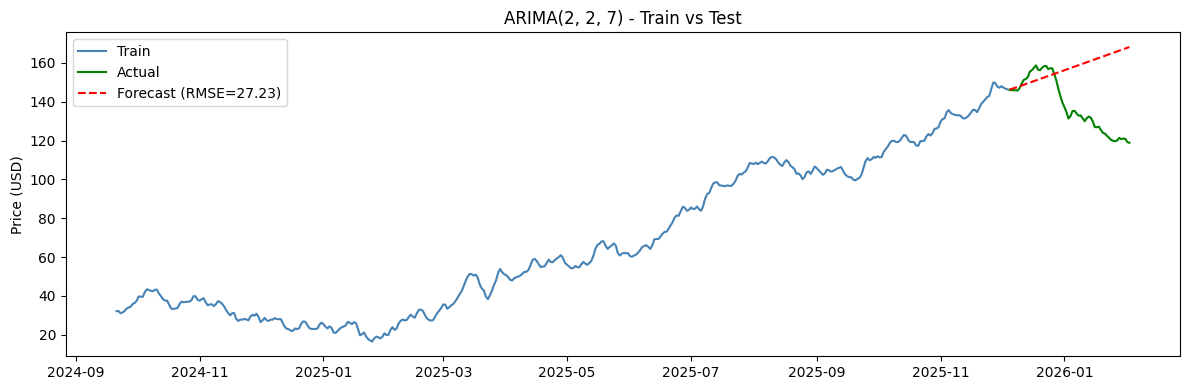

In [12]:
def evaluate_arima(series, order, test_size=60):
    train = series.iloc[:-test_size]
    test = series.iloc[-test_size:]

    fit = ARIMA(train, order=order).fit()
    preds = fit.forecast(steps=test_size)

    rmse = np.sqrt(mean_squared_error(test, preds))
    mae = mean_absolute_error(test, preds)
    mape = np.mean(np.abs((test.values - preds.values) / test.values)) * 100

    print(f'ARIMA{order} - Test Set ({test_size} days)')
    print(f'  RMSE: ${rmse:.2f}')
    print(f'  MAE:  ${mae:.2f}')
    print(f'  MAPE: {mape:.2f}%')

    plt.figure(figsize=(12, 4))
    plt.plot(train.index, train, color='steelblue', label='Train')
    plt.plot(test.index, test, color='green', label='Actual')
    plt.plot(test.index, preds, color='red', ls='--', label=f'Forecast (RMSE={rmse:.2f})')
    plt.title(f'ARIMA{order} - Train vs Test')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('fig5_arima_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    return rmse, mae, mape

arima_rmse, arima_mae, arima_mape = evaluate_arima(df['price'], best_order)

## 7. ARIMA 24-Month Forecast

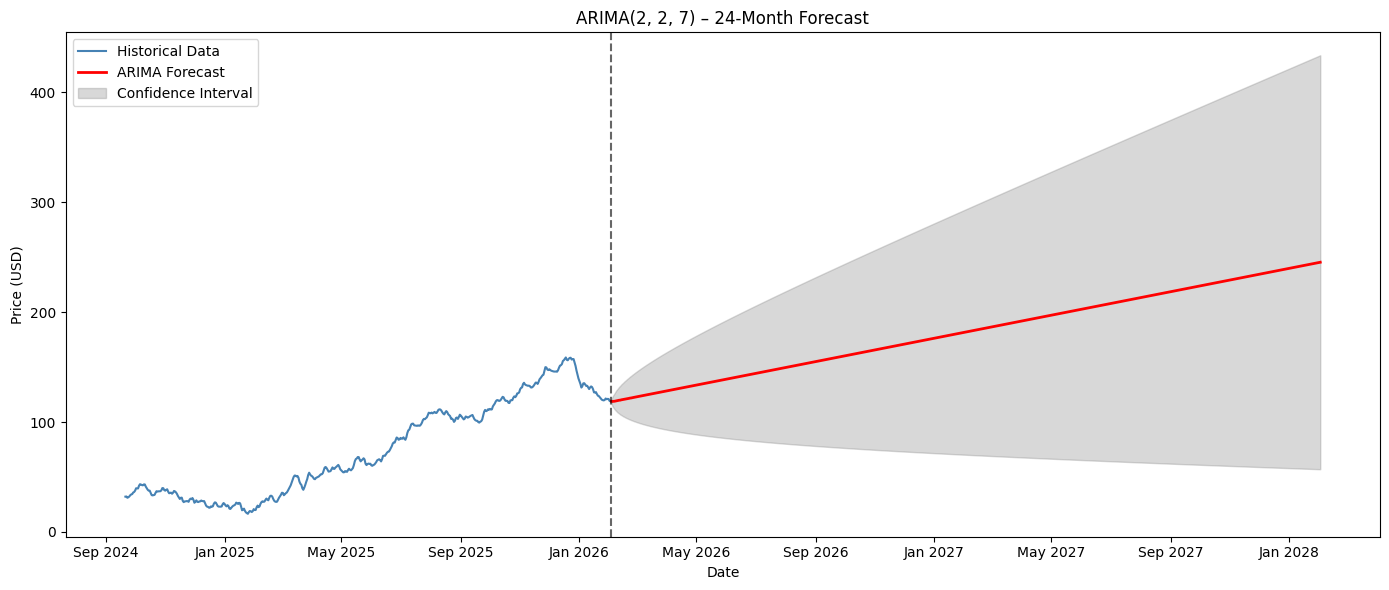

In [13]:
# Extract forecast mean + confidence intervals from the fitted ARIMA model
def get_forecast_data(model, steps=730):
    fc = model.get_forecast(steps=steps)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)
    return mean, ci


# Build the future date index for the forecast horizon
def build_forecast_index(series, steps=730):
    return pd.date_range(
        start=series.index[-1] + pd.Timedelta(days=1),
        periods=steps,
        freq='D'
    )


# Plot historical data, forecast, and confidence interval
def plot_arima_forecast(series, mean, ci, future_index, order):
    plt.figure(figsize=(14, 6))

    # historical series
    plt.plot(series.index, series, label="Historical Data", color="steelblue")

    # forecasted values
    plt.plot(future_index, mean, label="ARIMA Forecast", color="red", lw=2)

    # confidence interval shading
    plt.fill_between(
        future_index,
        ci.iloc[:, 0],
        ci.iloc[:, 1],
        color="gray",
        alpha=0.3,
        label="Confidence Interval"
    )

    # vertical line marking end of training data
    plt.axvline(series.index[-1], color="black", ls="--", alpha=0.6)

    plt.title(f"ARIMA{order} – 24‑Month Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.tight_layout()
    plt.savefig("fig6_arima_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()


# Wrapper function that ties everything together
def arima_forecast(series, model, order, steps=730):
    mean, ci = get_forecast_data(model, steps)
    future_index = build_forecast_index(series, steps)

    # align forecast outputs with the future date index
    mean.index = future_index
    ci.index = future_index

    plot_arima_forecast(series, mean, ci, future_index, order)
    return mean, ci


# Run the forecast
arima_fc, arima_ci = arima_forecast(df["price"], arima_fit, best_order)

---
## Part 2 - LSTM Model

Prepare data for LSTM model

## 8. Prepare Data for LSTM

In [14]:
def make_sequences(series, lookback=30, test_frac=0.15):
    values = series.values.reshape(-1, 1)
    split = int(len(values) * (1 - test_frac))

    # fit scaler on train only to avoid data leakage
    scaler = MinMaxScaler()
    scaler.fit(values[:split])
    scaled = scaler.transform(values)

    X, y = [], []
    for i in range(lookback, len(scaled)):
        X.append(scaled[i-lookback:i, 0])
        y.append(scaled[i, 0])
    X, y = np.array(X), np.array(y)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    split_adj = split - lookback
    return X[:split_adj], y[:split_adj], X[split_adj:], y[split_adj:], scaler, split

LOOKBACK = 30
X_train, y_train, X_test, y_test, scaler, split_idx = make_sequences(df['price'], LOOKBACK)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (395, 30, 1), Test: (75, 30, 1)


## 9. Build and Train LSTM

In [15]:
def build_lstm(lookback, units=64, dropout=0.2):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm = build_lstm(LOOKBACK)
lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0535 - val_loss: 0.0049
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0099 - val_loss: 0.0114
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 - val_loss: 0.0014
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0047 - val_loss: 7.2632e-04
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0048 - val_loss: 0.0038
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045 - val_loss: 7.2753e-04
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034 - val_loss: 0.0025
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0041 - val_loss: 0.0030
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0041 - val_loss: 0.0083
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0055 - val_loss: 7.5452e-04
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0048 - val_loss: 7.3763e-04
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━

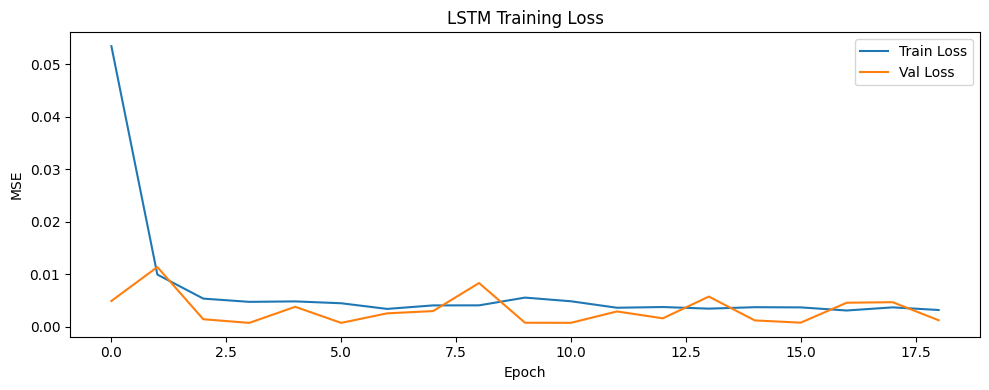

In [16]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = lstm.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# plot loss curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig('fig7_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 9b. Hyperparameter Tuning

In [17]:
def tune_lstm(series, configs):
    records = []
    for lb, units in configs:
        Xtr, ytr, Xte, yte, sc, _ = make_sequences(series, lb)
        m = build_lstm(lb, units)
        es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
        m.fit(Xtr, ytr, epochs=50, batch_size=32, validation_split=0.1, callbacks=[es], verbose=0)

        preds = sc.inverse_transform(m.predict(Xte, verbose=0)).flatten()
        actual = sc.inverse_transform(yte.reshape(-1,1)).flatten()
        rmse = np.sqrt(mean_squared_error(actual, preds))
        print(f'lookback={lb}, units={units}  =>  RMSE=${rmse:.2f}')
        records.append({'lookback': lb, 'units': units, 'RMSE': round(rmse, 2)})

    return pd.DataFrame(records).sort_values('RMSE').reset_index(drop=True)

configs = [(15, 64), (30, 32), (30, 64), (45, 64), (60, 64)]
tuning_results = tune_lstm(df['price'], configs)
print('\nTuning Results:')
print(tuning_results.to_string(index=False))

lookback=15, units=64  =>  RMSE=$7.14
lookback=30, units=32  =>  RMSE=$9.21
lookback=30, units=64  =>  RMSE=$8.49
lookback=45, units=64  =>  RMSE=$8.81
lookback=60, units=64  =>  RMSE=$8.27

Tuning Results:
 lookback  units  RMSE
       15     64  7.14
       60     64  8.27
       30     64  8.49
       45     64  8.81
       30     32  9.21


In [18]:
# retrain with best config
BEST_LB = int(tuning_results.iloc[0]['lookback'])
BEST_UNITS = int(tuning_results.iloc[0]['units'])

X_train, y_train, X_test, y_test, scaler, split_idx = make_sequences(df['price'], BEST_LB)
lstm = build_lstm(BEST_LB, BEST_UNITS)
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = lstm.fit(X_train, y_train, epochs=150, batch_size=32,
                   validation_split=0.1, callbacks=[es], verbose=1)

print(f'Final model: lookback={BEST_LB}, units={BEST_UNITS}')

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0665 - val_loss: 0.0072
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - val_loss: 0.0498
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051 - val_loss: 8.1136e-04
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044 - val_loss: 0.0018
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044 - val_loss: 7.8781e-04
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041 - val_loss: 0.0054
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0035 - val_loss: 0.0016
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - val_loss: 0.0021
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1

## 10. LSTM Test Performance

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
LSTM Test Metrics:
  RMSE: $6.49
  MAE:  $5.73
  MAPE: 4.14%


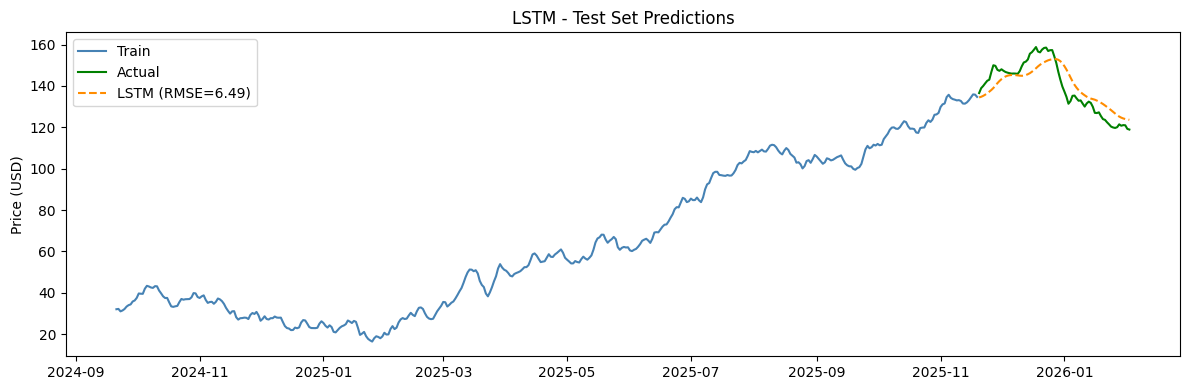

In [19]:
def evaluate_lstm(model, X_test, y_test, scaler, series, lookback):
    preds_sc = model.predict(X_test)
    preds = scaler.inverse_transform(preds_sc).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds) / actual)) * 100

    print(f'LSTM Test Metrics:')
    print(f'  RMSE: ${rmse:.2f}')
    print(f'  MAE:  ${mae:.2f}')
    print(f'  MAPE: {mape:.2f}%')

    test_dates = series.index[-len(actual):]
    train_end = series.index[-len(actual) - 1]

    plt.figure(figsize=(12, 4))
    plt.plot(series[series.index <= train_end], color='steelblue', label='Train')
    plt.plot(test_dates, actual, color='green', label='Actual')
    plt.plot(test_dates, preds, color='darkorange', ls='--', label=f'LSTM (RMSE={rmse:.2f})')
    plt.title('LSTM - Test Set Predictions')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('fig8_lstm_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    return rmse, mae, mape

lstm_rmse, lstm_mae, lstm_mape = evaluate_lstm(lstm, X_test, y_test, scaler, df['price'], BEST_LB)

## 11. LSTM 24-Month Forecast with Confidence Intervals

LSTM forecast with Monte Carlo dropout for uncertainty estimation

10/50 simulations complete
20/50 simulations complete
30/50 simulations complete
40/50 simulations complete
50/50 simulations complete


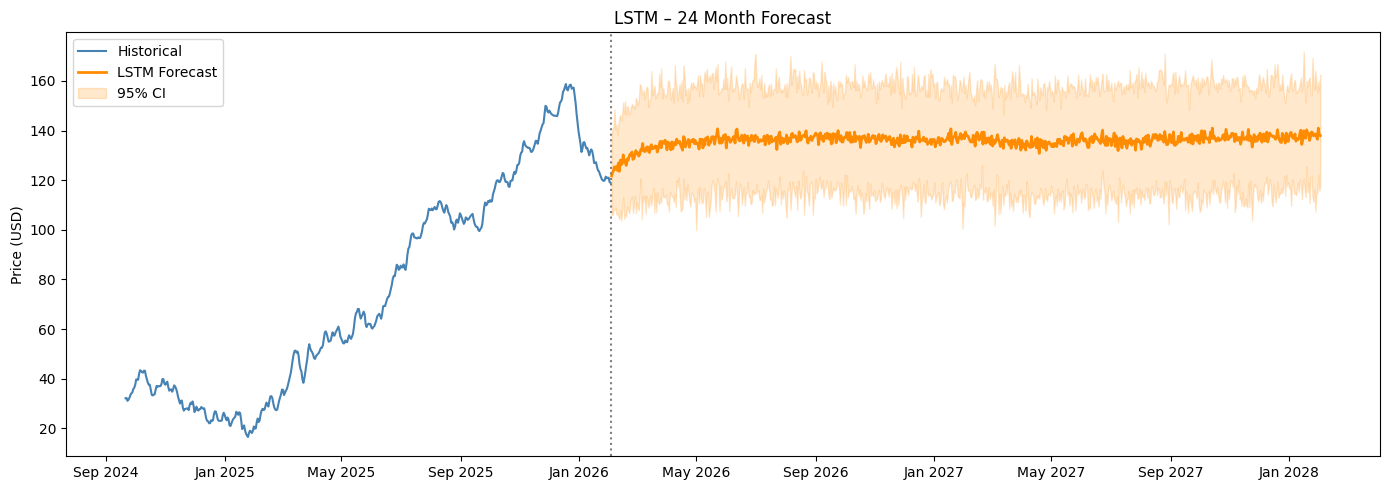

In [20]:
# Prepare input sequence for LSTM forecasting
def prepare_lstm_sequence(series, scaler, lookback):
    scaled = scaler.transform(series.values.reshape(-1, 1)).flatten()
    return scaled[-lookback:].copy()


# Run one stochastic simulation path using the trained LSTM
def simulate_lstm_path(model, start_seq, lookback, steps):
    seq = start_seq.copy()
    preds = []

    for _ in range(steps):
        # reshape to (1, lookback, 1) for LSTM input
        x_in = np.array(seq).reshape(1, lookback, 1)

        # predict next value
        pred = model(x_in, training=True).numpy()
        next_val = pred[0, 0]

        preds.append(next_val)

        # update sequence by dropping first value and appending prediction
        seq = np.append(seq[1:], next_val)

    return np.array(preds)


# Compute mean forecast + confidence intervals across simulations
def aggregate_simulations(sim_matrix, scaler):
    inv = scaler.inverse_transform(sim_matrix)
    inv = inv.reshape(sim_matrix.shape)

    mean = inv.mean(axis=0)
    lo = np.percentile(inv, 2.5, axis=0)
    hi = np.percentile(inv, 97.5, axis=0)

    return mean, lo, hi


# Plot historical data + LSTM forecast + CI
def plot_lstm_forecast(series, future_index, mean, lo, hi):
    plt.figure(figsize=(14, 5))

    plt.plot(series, color="steelblue", label="Historical")
    plt.plot(future_index, mean, color="darkorange", lw=2, label="LSTM Forecast")
    plt.fill_between(future_index, lo, hi, color="darkorange", alpha=0.2, label="95% CI")

    plt.axvline(series.index[-1], color="grey", ls=":")
    plt.title("LSTM – 24 Month Forecast")
    plt.ylabel("Price (USD)")
    plt.legend()

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.tight_layout()
    plt.savefig("fig9_lstm_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()


# Wrapper that ties everything together
def lstm_forecast(model, series, scaler, lookback, steps=730, n_sims=50):
    start_seq = prepare_lstm_sequence(series, scaler, lookback)
    all_sims = []

    for i in range(n_sims):
        sim = simulate_lstm_path(model, start_seq, lookback, steps)
        all_sims.append(sim)

        if (i + 1) % 10 == 0:
            print(f"{i+1}/{n_sims} simulations complete")

    all_sims = np.array(all_sims)

    # compute forecast statistics
    fc_mean, fc_lo, fc_hi = aggregate_simulations(all_sims, scaler)

    # build future date index
    future_index = pd.date_range(
        start=series.index[-1] + pd.Timedelta(days=1),
        periods=steps,
        freq="D"
    )

    # plot results
    plot_lstm_forecast(series, future_index, fc_mean, fc_lo, fc_hi)

    return future_index, fc_mean, fc_lo, fc_hi


# Run forecast
lstm_dates, lstm_mean, lstm_lo, lstm_hi = lstm_forecast(
    lstm, df["price"], scaler, BEST_LB
)

## 12. Model Comparison

In [21]:
# Helper function for comparison table

def build_comparison_table(arima_rmse, lstm_rmse, arima_mae, lstm_mae):
    comparison = pd.DataFrame({
        "Model": ["ARIMA", "LSTM"],
        "RMSE": [arima_rmse, lstm_rmse],
        "MAE": [arima_mae, lstm_mae]
    })
    return comparison

In [22]:
# Plot ARIMA and LSTM forecasts side by side

def plot_model_comparison(df, arima_fc, arima_ci, lstm_dates, lstm_mean, lstm_lo, lstm_hi,
                          best_order, BEST_LB, arima_rmse, lstm_rmse):
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ARIMA subplot
    axes[0].plot(df['price'], color='steelblue', label='Historical')
    axes[0].plot(arima_fc, color='red', lw=2, label='ARIMA Forecast')
    axes[0].fill_between(arima_ci.index, arima_ci.iloc[:,0], arima_ci.iloc[:,1],
                         color='red', alpha=0.15, label='95% CI')
    axes[0].axvline(df.index[-1], color='grey', ls=':')
    axes[0].set_title(f'ARIMA{best_order}   RMSE = ${arima_rmse:.2f}')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    # LSTM subplot
    axes[1].plot(df['price'], color='steelblue', label='Historical')
    axes[1].plot(lstm_dates, lstm_mean, color='darkorange', lw=2, label='LSTM Forecast')
    axes[1].fill_between(lstm_dates, lstm_lo, lstm_hi,
                         color='darkorange', alpha=0.2, label='95% CI')
    axes[1].axvline(df.index[-1], color='grey', ls=':')
    axes[1].set_title(f'LSTM (lb={BEST_LB})   RMSE = ${lstm_rmse:.2f}')
    axes[1].set_ylabel('Price (USD)')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.suptitle('ARIMA vs LSTM – 24‑Month Forecast Comparison')
    plt.tight_layout()
    plt.savefig('fig10_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
# Model comparison summary

def print_metric_summary(arima_rmse, lstm_rmse, arima_mae, lstm_mae, arima_mape, lstm_mape):
    print(f'\n{"Metric":<10} {"ARIMA":>10} {"LSTM":>10}')
    print('-' * 32)
    print(f'{"RMSE ($)":<10} {arima_rmse:>10.2f} {lstm_rmse:>10.2f}')
    print(f'{"MAE ($)":<10} {arima_mae:>10.2f} {lstm_mae:>10.2f}')
    print(f'{"MAPE (%)":<10} {arima_mape:>10.2f} {lstm_mape:>10.2f}')

In [24]:
# Comparison plot

def plot_metric_bars(comparison_df):
    comparison_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(8, 5))
    plt.title("Model Performance Comparison")
    plt.ylabel("Error")
    plt.tight_layout()
    plt.show()

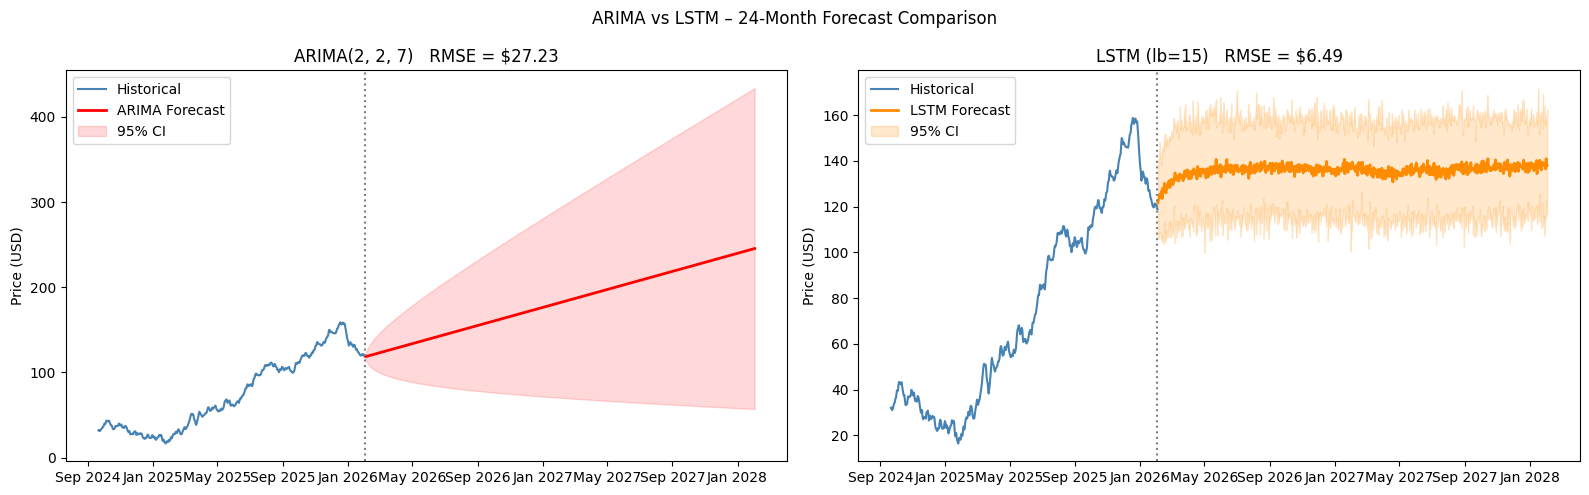


Metric          ARIMA       LSTM
--------------------------------
RMSE ($)        27.23       6.49
MAE ($)         21.32       5.73
MAPE (%)        16.74       4.14


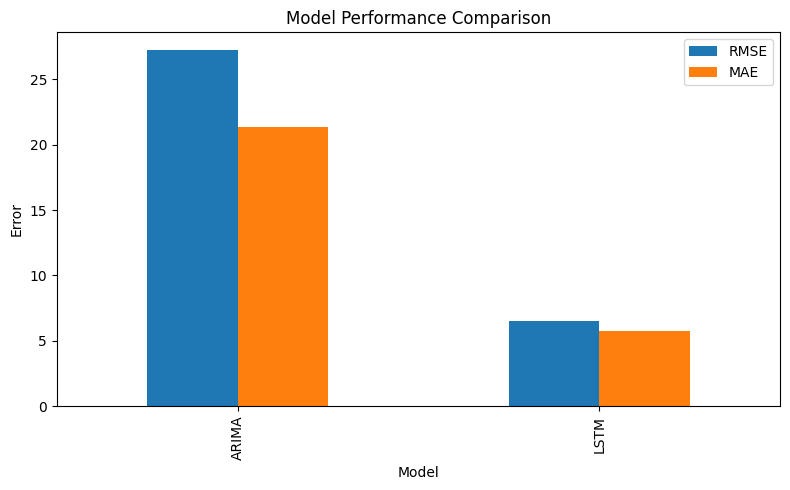

In [25]:
comparison_df = build_comparison_table(arima_rmse, lstm_rmse, arima_mae, lstm_mae)

plot_model_comparison(
    df, arima_fc, arima_ci,
    lstm_dates, lstm_mean, lstm_lo, lstm_hi,
    best_order, BEST_LB,
    arima_rmse, lstm_rmse
)

print_metric_summary(arima_rmse, lstm_rmse, arima_mae, lstm_mae, arima_mape, lstm_mape)

plot_metric_bars(comparison_df)

## 13. Forecast vs Real Post-February 2026 Prices

Load real post‑Feb 2026 prices for comparison

In [26]:
def load_real_prices():
    real_prices = {
        '2026-02-03': 72.5, '2026-02-04': 72.2, '2026-02-05': 71.8,
        '2026-02-09': 67.4, '2026-02-10': 68.0, '2026-02-17': 69.3,
        '2026-02-24': 70.1, '2026-03-02': 72.8, '2026-03-03': 76.1,
        '2026-03-04': 81.5, '2026-03-05': 87.2, '2026-03-06': 92.7
    }
    real_df = pd.Series(real_prices)
    real_df.index = pd.to_datetime(real_df.index)
    return real_df

def plot_forecast_vs_real(df, arima_fc, arima_ci, lstm_dates, lstm_mean,
                          real_df, best_order, BEST_LB, zoom_days=35):

    fig, ax = plt.subplots(figsize=(13, 5))

    # recent historical window
    ax.plot(df.index[-90:], df['price'].iloc[-90:], color='steelblue', lw=2, label='Historical')

    # ARIMA forecast (zoomed)
    ax.plot(arima_fc.index[:zoom_days], arima_fc.iloc[:zoom_days],
            color='red', ls='--', lw=2, label=f'ARIMA{best_order}')

    # LSTM forecast (zoomed)
    ax.plot(lstm_dates[:zoom_days], lstm_mean[:zoom_days],
            color='darkorange', ls='--', lw=2, label=f'LSTM (lb={BEST_LB})')

    # actual real-world prices
    ax.plot(real_df.index, real_df.values, 'ko-', ms=6, lw=2, label='Actual (Brent Crude)')

    ax.axvline(df.index[-1], color='grey', ls=':', label='Forecast Start')

    ax.set_title('Forecasts vs Real Prices (Feb–Mar 2026)')
    ax.set_ylabel('Price (USD/barrel)')
    ax.legend()

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.savefig('fig11_vs_real.png', dpi=150, bbox_inches='tight')
    plt.show()

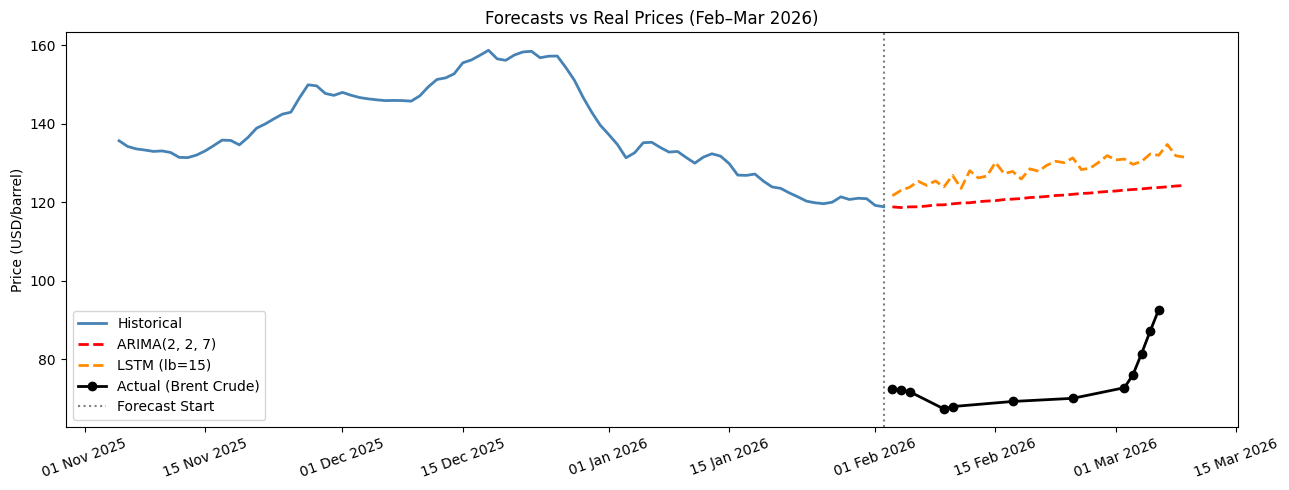

In [27]:
real_df = load_real_prices()

plot_forecast_vs_real(
    df,
    arima_fc, arima_ci,
    lstm_dates, lstm_mean,
    real_df,
    best_order, BEST_LB,
    zoom_days=35
)

## 14. Summary of key model results

In [28]:
print("\n=== Final Model Summary ===")
print(f"Best ARIMA order: {best_order}")
print(f"ARIMA RMSE:       {arima_rmse:.3f}")
print(f"LSTM RMSE:        {lstm_rmse:.3f}")


=== Final Model Summary ===
Best ARIMA order: (2, 2, 7)
ARIMA RMSE:       27.232
LSTM RMSE:        6.495
